In [10]:
import sys, os
sys.path.insert(0, os.path.expanduser('~/local/aispy'))
sys.path.insert(0, os.path.expanduser('~/aispp-sims/gaussian-wavefront-spatially-resolved-inference/helpers/'))

import numpy as np
import matplotlib.pyplot as plt

from aispy.psmap import load_psmap, PSMAPSurrogate

In [11]:
# define the Poisson-loglikelihood
from scipy.special import gammaln

def ll_poisson(count, rate):
    # count is observed count (k) rate is rate (lambda)
    return count * np.log(rate) - rate - gammaln(count + 1)

# define the phase space distribution at detection time 
import numpy as np

def pdf_v_given_x(vx, vy, x, y, t, params):
    mux0, muvx0, muy0, muvy0, sx0, svx0, sy0, svy0 = params

    # Conditional means
    gain_x = t * svx0**2 / (sx0**2 + t**2 * svx0**2)
    gain_y = t * svy0**2 / (sy0**2 + t**2 * svy0**2)

    mu_vx_given_x = muvx0 + gain_x * (x - mux0 - t * muvx0)
    mu_vy_given_y = muvy0 + gain_y * (y - muy0 - t * muvy0)

    # Conditional variances
    var_vx_given_x = sx0**2 * svx0**2 / (sx0**2 + t**2 * svx0**2)
    var_vy_given_y = sy0**2 * svy0**2 / (sy0**2 + t**2 * svy0**2)

    # Independent x/y conditional Gaussian factors
    pdf_vx = (
        1.0 / np.sqrt(2.0 * np.pi * var_vx_given_x)
        * np.exp(-0.5 * (vx - mu_vx_given_x)**2 / var_vx_given_x)
    )

    pdf_vy = (
        1.0 / np.sqrt(2.0 * np.pi * var_vy_given_y)
        * np.exp(-0.5 * (vy - mu_vy_given_y)**2 / var_vy_given_y)
    )

    return pdf_vx * pdf_vy

In [12]:
# start by getting the psmaps
psmap_z0 = load_psmap('../output-files/PSGRID4D_CONFOCAL_FINE_Z0.h5')
psmap_z100 = load_psmap('../output-files/PSGRID4D_CONFOCAL_FINE_Z100.h5')

surrogate_z0   = PSMAPSurrogate(psmap_z0, t_det=3.8, use_gpu=True)
surrogate_z100 = PSMAPSurrogate(psmap_z100, t_det=3.8, use_gpu=True)

In [13]:
from numpy.polynomial.hermite import hermgauss
from scipy.special import logsumexp

GH_N = 12
gh_nodes, gh_weights = hermgauss(GH_N)
N_PHI = 128
IDX = 0

BIN_FACTOR = 8

def rebin_histogram_2d(data, bin_factor):
    n = data.shape[0] // bin_factor
    return data.reshape(n, bin_factor, n, bin_factor).sum(axis=(1, 3))

def rebin_edges(edges, bin_factor):
    return edges[::bin_factor]


def v_given_x_params(x, y, t, params):
    """Mean and variance of p(vx, vy | xf, yf)."""
    mux0, muvx0, muy0, muvy0, sx0, svx0, sy0, svy0 = params
    gain_x = t * svx0**2 / (sx0**2 + t**2 * svx0**2)
    gain_y = t * svy0**2 / (sy0**2 + t**2 * svy0**2)
    mu_vx = muvx0 + gain_x * (x - mux0 - t * muvx0)
    mu_vy = muvy0 + gain_y * (y - muy0 - t * muvy0)
    var_vx = sx0**2 * svx0**2 / (sx0**2 + t**2 * svx0**2)
    var_vy = sy0**2 * svy0**2 / (sy0**2 + t**2 * svy0**2)
    return mu_vx, mu_vy, var_vx, var_vy


def pixel_prob(x, y, t, params):
    """Marginal Gaussian density × pixel_area = P(atom lands in pixel)."""
    mux0, muvx0, muy0, muvy0, sx0, svx0, sy0, svy0 = params
    mu_xf = mux0 + muvx0 * t;  mu_yf = muy0 + muvy0 * t
    var_xf = sx0**2 + (svx0 * t)**2;  var_yf = sy0**2 + (svy0 * t)**2
    px = np.exp(-0.5*(x-mu_xf)**2/var_xf) / np.sqrt(2*np.pi*var_xf)
    py = np.exp(-0.5*(y-mu_yf)**2/var_yf) / np.sqrt(2*np.pi*var_yf)
    return px * py


def rates_ACS(z, x, y, t_det, params):
    """
    GH-integrate ACS over p(vx, vy | xf, yf) for ALL ports.

    Returns (A_g, C_g, S_g), (A_e, C_e, S_e) for ground/excited state.
    rate_state(pixel, phi0) = A_state + C_state*cos(phi0) + S_state*sin(phi0)
    """
    mu_vx, mu_vy, var_vx, var_vy = v_given_x_params(x, y, t_det, params)
    N_pix = len(x)
    vx_nodes = mu_vx[:, None] + np.sqrt(2 * var_vx) * gh_nodes  # (N_pix, GH_N)
    vy_nodes = mu_vy[:, None] + np.sqrt(2 * var_vy) * gh_nodes
    vx_g = np.broadcast_to(vx_nodes[:, :, None], (N_pix, GH_N, GH_N)).copy()
    vy_g = np.broadcast_to(vy_nodes[:, None, :], (N_pix, GH_N, GH_N)).copy()
    x0 = x[:, None, None] - vx_g * t_det
    y0 = y[:, None, None] - vy_g * t_det

    surrogate = surrogate_z0 if z == 0 else surrogate_z100
    dphi_all, a0_all, a1_all = surrogate.eval(
        x0.reshape(-1), y0.reshape(-1), vx_g.reshape(-1), vy_g.reshape(-1))
    # dphi_all, a0_all, a1_all: (N_pix*GH_N*GH_N, nP)

    weights = np.outer(gh_weights, gh_weights) / np.pi  # (GH_N, GH_N)
    A_g = np.zeros(N_pix); C_g = np.zeros(N_pix); S_g = np.zeros(N_pix)
    A_e = np.zeros(N_pix); C_e = np.zeros(N_pix); S_e = np.zeros(N_pix)

    for pi in range(surrogate.nP):
        dphi = dphi_all[:, pi].reshape(N_pix, GH_N, GH_N)
        a0   =   a0_all[:, pi].reshape(N_pix, GH_N, GH_N)
        a1   =   a1_all[:, pi].reshape(N_pix, GH_N, GH_N)
        inter = float(surrogate.port_interfering[pi])
        A_  = np.einsum('ij,pij->p', weights, a0**2 + a1**2)
        C_  = np.einsum('ij,pij->p', weights, inter * 2*a0*a1*np.cos(dphi))
        S_  = np.einsum('ij,pij->p', weights, inter * (-2*a0*a1*np.sin(dphi)))
        if surrogate.port_states[pi] == 0:
            A_g += A_; C_g += C_; S_g += S_
        else:
            A_e += A_; C_e += C_; S_e += S_

    return (A_g, C_g, S_g), (A_e, C_e, S_e)


def ll_image_joint(counts_g, counts_e, x, y, z, t_det, params, n_atoms, pixel_area):
    """
    Joint phi0-marginalised Poisson log-likelihood for both output states.

    counts_g, counts_e : (N_pix,) ground / excited state image counts
    Phi0 is treated as a uniform nuisance and marginalised over N_PHI points.
    """
    (A_g, C_g, S_g), (A_e, C_e, S_e) = rates_ACS(z, x, y, t_det, params)
    p_pix = pixel_prob(x, y, t_det, params) * pixel_area  # (N_pix,)
    phi = np.linspace(0, 2*np.pi, N_PHI, endpoint=False)

    lam_g = n_atoms * p_pix[:, None] * np.maximum(
        A_g[:,None] + C_g[:,None]*np.cos(phi) + S_g[:,None]*np.sin(phi), 1e-300)
    lam_e = n_atoms * p_pix[:, None] * np.maximum(
        A_e[:,None] + C_e[:,None]*np.cos(phi) + S_e[:,None]*np.sin(phi), 1e-300)

    ll_per_phi = (ll_poisson(counts_g[:, None], lam_g) +
                  ll_poisson(counts_e[:, None], lam_e)).sum(0)
    return logsumexp(ll_per_phi) - np.log(N_PHI)

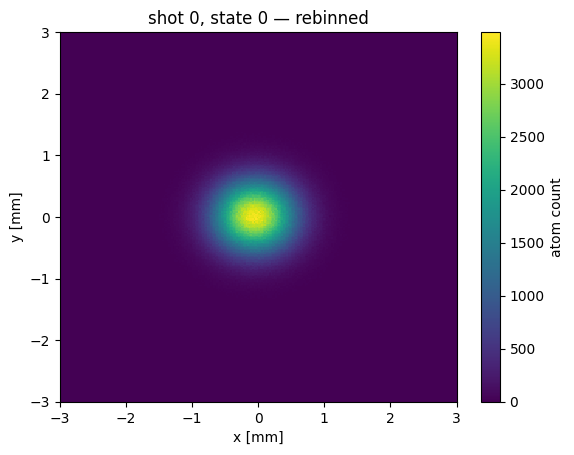

BINS=256, pixel_size=2.3438e-05 m, xc[0]=-2988.28 µm


In [14]:
from helpers import ImageShotDataset

Z0   = ImageShotDataset('/home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/data/R20_N200_A100000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000/run_000/Z0/data_IMG.h5')
Z100 = ImageShotDataset('/home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/data/R20_N200_A100000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000/run_000/Z100/data_IMG.h5')

# Coarse edges: every BIN_FACTOR-th fine edge
edges = Z0.edges[::BIN_FACTOR]              # (res//BIN_FACTOR + 1,)
# Correct coarse pixel centres: midpoints of coarse bins
xc    = 0.5 * (edges[:-1] + edges[1:])     # (res//BIN_FACTOR,)

# Rebinned display image
shot_img_coarse = rebin_histogram_2d(Z0[IDX][0].astype(float), BIN_FACTOR)

Xc, Yc = np.meshgrid(xc, xc, indexing='ij')
pixel_area = (xc[1] - xc[0])**2

X, Y = np.meshgrid(edges, edges)
plt.pcolormesh(X * 1e3, Y * 1e3, shot_img_coarse)
plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
plt.title('shot 0, state 0 — rebinned')
plt.colorbar(label='atom count')
plt.show()

print(f'BINS={len(xc)}, pixel_size={xc[1]-xc[0]:.4e} m, xc[0]={xc[0]*1e6:.2f} µm')

In [15]:
n_atoms    = Z0.n_atoms_launched
pixel_area = (xc[1] - xc[0])**2

Xc, Yc = np.meshgrid(xc, xc, indexing='ij')  # (BINS, BINS) coarse grid

# Both states, properly rebinned (block-sum, not subsampling)
shot_s0_z0   = rebin_histogram_2d(Z0[IDX][0].astype(float), BIN_FACTOR)
shot_s1_z0   = rebin_histogram_2d(Z0[IDX][1].astype(float), BIN_FACTOR)
shot_s0_z100 = rebin_histogram_2d(Z100[IDX][0].astype(float), BIN_FACTOR)
shot_s1_z100 = rebin_histogram_2d(Z100[IDX][1].astype(float), BIN_FACTOR)

true_params_Z0 = [Z0.mu_x0[IDX], Z0.mu_vx0[IDX], Z0.mu_y0[IDX], Z0.mu_vy0[IDX],
                  Z0.sigma_x[IDX], Z0.sigma_vx[IDX], Z0.sigma_y[IDX], Z0.sigma_vy[IDX]]
true_params_Z100 = [Z100.mu_x0[IDX], Z100.mu_vx0[IDX], Z100.mu_y0[IDX], Z100.mu_vy0[IDX],
                    Z100.sigma_x[IDX], Z100.sigma_vx[IDX], Z100.sigma_y[IDX], Z100.sigma_vy[IDX]]

print(f"n_atoms={n_atoms:,}  pixel_area={pixel_area*1e12:.0f} µm²")
print(f"Z0  s0 counts={shot_s0_z0.sum():.0f}  s1 counts={shot_s1_z0.sum():.0f}")
print(f"Z100 s0 counts={shot_s0_z100.sum():.0f}  s1 counts={shot_s1_z100.sum():.0f}")
print(f"true mux0={true_params_Z0[0]*1e6:.2f} µm  true muvx0={true_params_Z0[1]*1e6:.2f} µm/s")

# Sanity-check logL at true params
result = ll_image_joint(
    shot_s0_z0.flatten(), shot_s1_z0.flatten(),
    Xc.flatten(), Yc.flatten(),
    0, 3.8, true_params_Z0, n_atoms, pixel_area,
)
print(f"logL(true_params_Z0) = {result:.2f}")

n_atoms=100,000,000  pixel_area=549 µm²
Z0  s0 counts=6541281  s1 counts=84440875
Z100 s0 counts=31391056  s1 counts=45140841
true mux0=6.15 µm  true muvx0=2.26 µm/s
logL(true_params_Z0) = -533521.36


In [ ]:
mux0_scan = np.linspace(-30e-6, 30e-6, 21)

from tqdm import tqdm
ll_val = []
for i in tqdm(range(len(mux0_scan))):
    params_z0   = [mux0_scan[i]] + true_params_Z0[1:]
    params_z100 = true_params_Z100
    result_z0   = ll_image_joint(
        shot_s0_z0.flatten(), shot_s1_z0.flatten(),
        Xc.flatten(), Yc.flatten(),
        0, 3.8, params_z0, n_atoms, pixel_area)
    result_z100 = ll_image_joint(
        shot_s0_z100.flatten(), shot_s1_z100.flatten(),
        Xc.flatten(), Yc.flatten(),
        100, 3.8, params_z100, n_atoms, pixel_area)
    ll_val.append(result_z0 + result_z100)

ll_arr = np.array(ll_val)
ll_arr -= ll_arr.max()
print(f"Peak at mux0={mux0_scan[np.argmax(ll_arr)]*1e6:.1f} µm  (true Z0={true_params_Z0[0]*1e6:.2f} µm)")

  0%|          | 0/21 [00:00<?, ?it/s]

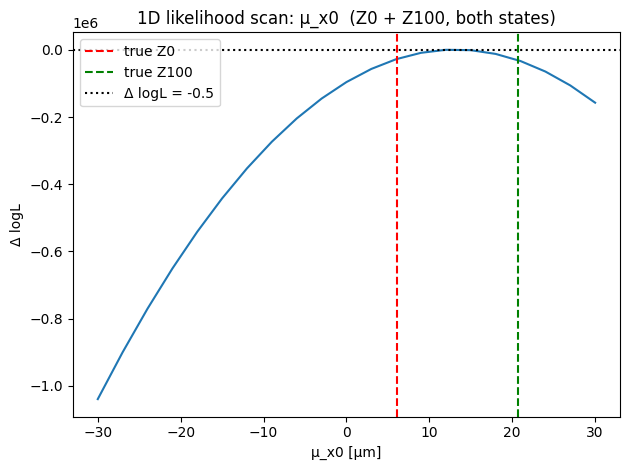

In [ ]:
fig, ax = plt.subplots()
ax.plot(mux0_scan * 1e6, ll_arr)
ax.axvline(true_params_Z0[0] * 1e6, color='r', linestyle='--', label='true Z0')
ax.axvline(true_params_Z100[0] * 1e6, color='g', linestyle='--', label='true Z100')
ax.axhline(-0.5, color='k', linestyle=':', label='Δ logL = -0.5')
ax.set_xlabel('μ_x0 [µm]')
ax.set_ylabel('Δ logL')
ax.set_title('1D likelihood scan: μ_x0  (Z0 + Z100, both states)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
true_params

NameError: name 'true_params' is not defined